In [2]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 5, 'hathodawala': 1, 'is': 2, 'looking': 4, 'for': 0, 'job': 3}

In [6]:
# bi-gram
v = CountVectorizer(ngram_range=(1,2))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 9,
 'hathodawala': 2,
 'is': 4,
 'looking': 7,
 'for': 0,
 'job': 6,
 'thor hathodawala': 10,
 'hathodawala is': 3,
 'is looking': 5,
 'looking for': 8,
 'for job': 1}

In [5]:
# tri-gram
v = CountVectorizer(ngram_range=(1,3))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 12,
 'hathodawala': 2,
 'is': 5,
 'looking': 9,
 'for': 0,
 'job': 8,
 'thor hathodawala': 13,
 'hathodawala is': 3,
 'is looking': 6,
 'looking for': 10,
 'for job': 1,
 'thor hathodawala is': 14,
 'hathodawala is looking': 4,
 'is looking for': 7,
 'looking for job': 11}

In [8]:
# Text Pre-Prossing
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm") 

def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens) 

In [9]:
preprocess("Thor ate pizza")

'thor eat pizza'

In [10]:
preprocess("Loki is eating pizza")

'Loki eat pizza'

In [12]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

corpus_processed = [
    preprocess(text) for text in corpus
]
corpus_processed

['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [13]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(corpus_processed)
v.vocabulary_

{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

In [14]:
v.transform(["Thor eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 1, 1]])

In [15]:
v.transform(["Hulk eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 0, 0]])

In [21]:
import pandas as pd

df = pd.read_json(
    r"F:\Codes\NLP\News_Category_Dataset.json",
    lines=True
)

print(df.shape)
df.head()

(124989, 6)


,short_description,headline,date,link,authors,category
0,She left her husband. He killed their children...,There Were 2 Mass Shootings In Texas Last Week...,2018-05-26,https://www.huffingtonpost.com/entry/texas-ama...,Melissa Jeltsen,CRIME
1,Of course it has a song.,Will Smith Joins Diplo And Nicky Jam For The 2...,2018-05-26,https://www.huffingtonpost.com/entry/will-smit...,Andy McDonald,ENTERTAINMENT
2,The actor and his longtime girlfriend Anna Ebe...,Hugh Grant Marries For The First Time At Age 57,2018-05-26,https://www.huffingtonpost.com/entry/hugh-gran...,Ron Dicker,ENTERTAINMENT
3,The actor gives Dems an ass-kicking for not fi...,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,2018-05-26,https://www.huffingtonpost.com/entry/jim-carre...,Ron Dicker,ENTERTAINMENT
4,"The ""Dietland"" actress said using the bags is ...",Julianna Margulies Uses Donald Trump Poop Bags...,2018-05-26,https://www.huffingtonpost.com/entry/julianna-...,Ron Dicker,ENTERTAINMENT


In [22]:
df.category.value_counts()

category
POLITICS          32739
ENTERTAINMENT     14257
HEALTHY LIVING     6694
QUEER VOICES       4995
BUSINESS           4254
SPORTS             4167
COMEDY             3971
PARENTS            3955
BLACK VOICES       3858
THE WORLDPOST      3664
WOMEN              3490
CRIME              2893
MEDIA              2815
WEIRD NEWS         2670
GREEN              2622
IMPACT             2602
WORLDPOST          2579
RELIGION           2556
STYLE              2254
WORLD NEWS         2177
TRAVEL             2145
TASTE              2096
ARTS               1509
FIFTY              1401
GOOD NEWS          1398
SCIENCE            1381
ARTS & CULTURE     1339
TECH               1231
COLLEGE            1144
LATINO VOICES      1129
EDUCATION          1004
Name: count, dtype: int64

In [23]:
min_samples = 1381 # we have these many SCIENCE articles and SCIENCE is our minority class

df_business = df[df.category=="BUSINESS"].sample(min_samples, random_state=2022)
df_sports = df[df.category=="SPORTS"].sample(min_samples, random_state=2022)
df_crime = df[df.category=="CRIME"].sample(min_samples, random_state=2022)
df_science = df[df.category=="SCIENCE"].sample(min_samples, random_state=2022)

In [24]:
df_balanced = pd.concat([df_business,df_sports,df_crime,df_science],axis=0)
df_balanced.category.value_counts()

category
BUSINESS    1381
SPORTS      1381
CRIME       1381
SCIENCE     1381
Name: count, dtype: int64

In [25]:
# Convert text category to a number
target = {'BUSINESS': 0, 'SPORTS': 1, 'CRIME': 2, 'SCIENCE': 3}

df_balanced['category_num'] = df_balanced['category'].map({
    'BUSINESS': 0,
    'SPORTS': 1, 
    'CRIME': 2, 
    'SCIENCE': 3
})

df_balanced.head()

,short_description,headline,date,link,authors,category,category_num
120663,Conscious awareness of the comfort principle i...,Obstacles for Women in Business: The Comfort P...,2014-06-08,https://www.huffingtonpost.com/entry/obstacles...,"Caroline Turner, ContributorAuthor, workshop f...",BUSINESS,0
57531,,5 Business Lessons You Can Learn from Fitness ...,2016-05-29,https://www.huffingtonpost.com/entry/5-busines...,"AJ Agrawal, Contributor",BUSINESS,0
61632,Other regulators are stepping up while the SEC...,Obama’s Wall Street Watchdog Does Little To Pr...,2016-04-12,https://www.huffingtonpost.com/entry/barack-ob...,Shahien Nasiripour,BUSINESS,0
13088,"Men run everything, and it's enough already. W...",The Lack Of Women Leaders Is A National Emergency,2017-10-28,https://www.huffingtonpost.com/entry/women-lea...,Emily Peck,BUSINESS,0
80943,The stand-out national problem we have today i...,Profit Sharing: Labor's New Opportunity,2015-09-06,https://www.huffingtonpost.com/entry/profit-sh...,"Joseph Blasi, ContributorJ. Robert Beyster Dis...",BUSINESS,0


In [30]:
# Build a model with original text (no pre processing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.short_description, 
    df_balanced.category_num, 
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df_balanced.category_num
)

print(X_train.shape)
X_train.head()

(4419,)


88842     It's a big time at NASA.  Scientific probes ar...
112076    Canadian researchers found that during ovulati...
83279                                        A costly goal.
26755     One victim says it's too extreme to be called ...
37798     Without warning, he pulls out a 9mm semi-autom...
Name: short_description, dtype: object

In [29]:
print(df_balanced.columns)

Index(['short_description', 'headline', 'date', 'link', 'authors', 'category',
       'category_num'],
      dtype='object')


In [31]:
y_train.value_counts()

category_num
3    1105
2    1105
0    1105
1    1104
Name: count, dtype: int64

In [32]:
y_test.value_counts()

category_num
1    277
0    276
3    276
2    276
Name: count, dtype: int64

In [33]:
# 1-gram = a Bag Of Words (BOW) model

from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_bow', CountVectorizer(ngram_range = (1, 1))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.91      0.58       276
           1       0.83      0.46      0.59       277
           2       0.74      0.58      0.65       276
           3       0.78      0.43      0.56       276

    accuracy                           0.59      1105
   macro avg       0.69      0.59      0.60      1105
weighted avg       0.69      0.59      0.60      1105



In [34]:
# 1-gram and bigrams

#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_1_2_gram', CountVectorizer(ngram_range = (1, 2))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.92      0.56       276
           1       0.85      0.42      0.56       277
           2       0.78      0.55      0.64       276
           3       0.77      0.37      0.50       276

    accuracy                           0.56      1105
   macro avg       0.70      0.56      0.56      1105
weighted avg       0.70      0.56      0.56      1105



In [35]:
# 1-gram to trigrams

#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_1_3_grams', CountVectorizer(ngram_range = (1, 3))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.92      0.54       276
           1       0.84      0.39      0.53       277
           2       0.78      0.55      0.64       276
           3       0.76      0.34      0.47       276

    accuracy                           0.55      1105
   macro avg       0.69      0.55      0.55      1105
weighted avg       0.69      0.55      0.55      1105



In [38]:
# pre-processing to remove stop words, punctuations and apply lemmatization
df_balanced['preprocessed_txt'] = df_balanced['short_description'].apply(preprocess)
df_balanced.head()

,short_description,headline,date,link,authors,category,category_num,preprocessed_txt
120663,Conscious awareness of the comfort principle i...,Obstacles for Women in Business: The Comfort P...,2014-06-08,https://www.huffingtonpost.com/entry/obstacles...,"Caroline Turner, ContributorAuthor, workshop f...",BUSINESS,0,conscious awareness comfort principle cure ack...
57531,,5 Business Lessons You Can Learn from Fitness ...,2016-05-29,https://www.huffingtonpost.com/entry/5-busines...,"AJ Agrawal, Contributor",BUSINESS,0,
61632,Other regulators are stepping up while the SEC...,Obama’s Wall Street Watchdog Does Little To Pr...,2016-04-12,https://www.huffingtonpost.com/entry/barack-ob...,Shahien Nasiripour,BUSINESS,0,regulator step SEC ignore climate change
13088,"Men run everything, and it's enough already. W...",The Lack Of Women Leaders Is A National Emergency,2017-10-28,https://www.huffingtonpost.com/entry/women-lea...,Emily Peck,BUSINESS,0,man run want stop sexual harassment fix
80943,The stand-out national problem we have today i...,Profit Sharing: Labor's New Opportunity,2015-09-06,https://www.huffingtonpost.com/entry/profit-sh...,"Joseph Blasi, ContributorJ. Robert Beyster Dis...",BUSINESS,0,stand national problem today recent decade pro...


In [39]:
print(df_balanced.columns)

Index(['short_description', 'headline', 'date', 'link', 'authors', 'category',
       'category_num', 'preprocessed_txt'],
      dtype='object')


In [40]:
# Build a model with pre processed text
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.preprocessed_txt, 
    df_balanced.category_num, 
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df_balanced.category_num
)

In [41]:
#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range = (1, 2))),        #using the ngram_range parameter 
    ('Multi NB', MultinomialNB())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.92      0.60       276
           1       0.82      0.47      0.60       277
           2       0.72      0.57      0.64       276
           3       0.80      0.45      0.58       276

    accuracy                           0.60      1105
   macro avg       0.70      0.60      0.60      1105
weighted avg       0.70      0.60      0.60      1105



In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[254,   2,  14,   6],
       [102, 131,  30,  14],
       [ 93,  14, 158,  11],
       [120,  13,  18, 125]])

Text(95.72222222222221, 0.5, 'Truth')

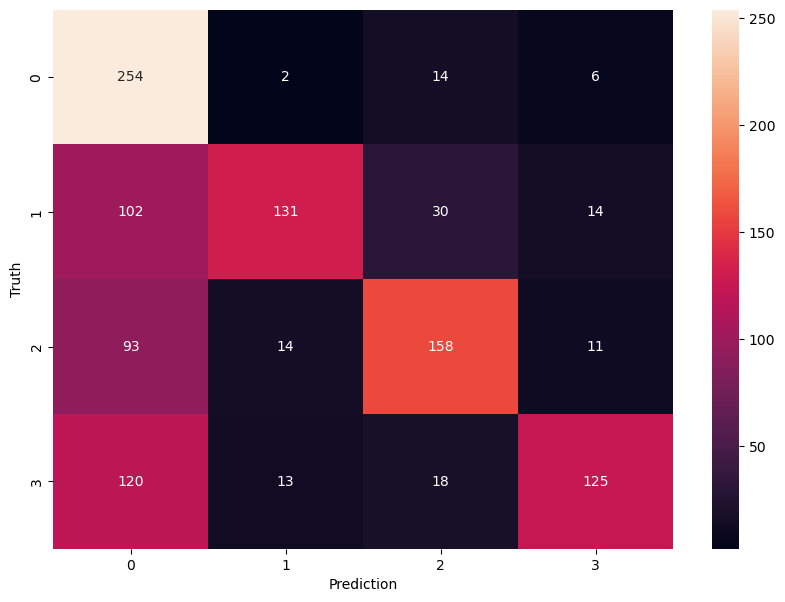

In [43]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')